In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,5)

In [8]:
df = pd.read_csv("funnel_events_dataset.csv")

In [9]:
df.head()

,user_id,session_id,feature_name,funnel_stage,stage_order,stage_completed,time_spent_stage_seconds,exit_stage,dropoff_flag,error_flag,rage_clicks,retries,device_type,traffic_source,timestamp
0,U003229,FS00000001,Watch Party,Seen,1,1,46,NaN,0,0,0,0,mobile,referral,2024-10-17 20:25:46
1,U003229,FS00000001,Watch Party,Clicked,2,1,43,NaN,0,0,1,0,mobile,referral,2024-10-17 20:26:29
2,U003229,FS00000001,Watch Party,Room Created,3,0,67,Room Created,1,0,0,0,mobile,referral,2024-10-17 20:27:36
3,U010281,FS00000002,Watch Party,Seen,1,1,208,NaN,0,1,0,1,desktop,referral,2024-12-30 18:49:28
4,U010281,FS00000002,Watch Party,Clicked,2,0,204,Clicked,1,0,0,0,desktop,referral,2024-12-30 18:52:52


In [10]:
print("=" * 60)
print("FUNNEL DATASET OVERVIEW")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

FUNNEL DATASET OVERVIEW

Shape:
(116245, 15)

Columns:
Index(['user_id', 'session_id', 'feature_name', 'funnel_stage', 'stage_order',
       'stage_completed', 'time_spent_stage_seconds', 'exit_stage',
       'dropoff_flag', 'error_flag', 'rage_clicks', 'retries', 'device_type',
       'traffic_source', 'timestamp'],
      dtype='object')

First 5 Rows:
   user_id  session_id feature_name  funnel_stage  stage_order  \
0  U003229  FS00000001  Watch Party          Seen            1   
1  U003229  FS00000001  Watch Party       Clicked            2   
2  U003229  FS00000001  Watch Party  Room Created            3   
3  U010281  FS00000002  Watch Party          Seen            1   
4  U010281  FS00000002  Watch Party       Clicked            2   

   stage_completed  time_spent_stage_seconds    exit_stage  dropoff_flag  \
0                1                        46           NaN             0   
1                1                        43           NaN             0   
2                0 

# TIMESTAMP CONVERSION

In [11]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

 # FUNNEL STAGE DISTRIBUTION

In [12]:
print("=" * 60)
print("FUNNEL STAGE DISTRIBUTION")
print("=" * 60)

stage_distribution = (

    df["funnel_stage"]
    .value_counts()

)

print(stage_distribution)

FUNNEL STAGE DISTRIBUTION
funnel_stage
Download Seen             9000
Download Started          9000
Recommendation Seen       8000
Recommendation Clicked    8000
Add to Watchlist          7500
Watchlist Opened          7500
Download Completed        6965
Preview Seen              6500
Preview Watched           6500
Offline Watch Started     5931
Movie Started             5660
Seen                      5000
Clicked                   5000
Content Played            4953
Feature Reused            4822
Movie Completed           4115
Content Opened            3651
Watch Completed           3502
Room Created              2217
Content Completed         1321
Friends Invited            860
Session Started            193
Session Completed           55
Name: count, dtype: int64


/tmp/ipykernel_2409/459039475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


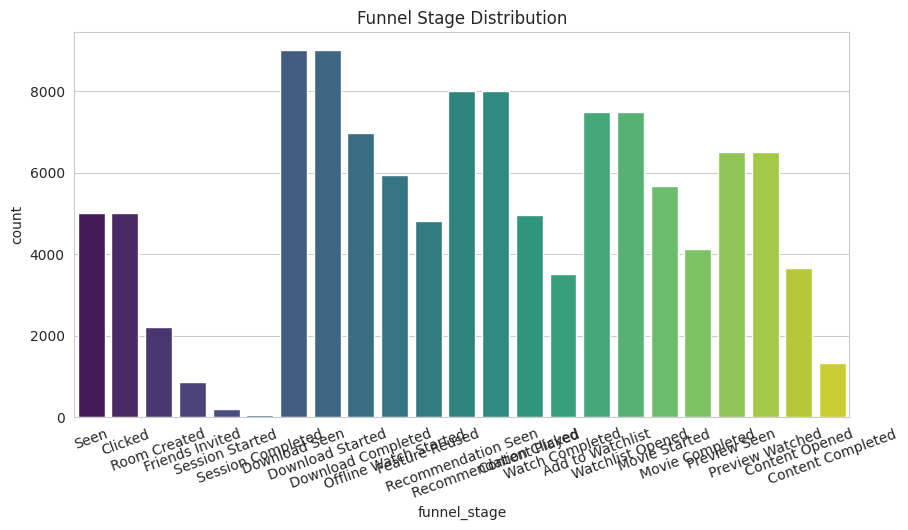

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="funnel_stage",
    palette="viridis"
)

plt.title("Funnel Stage Distribution")

plt.xticks(rotation=20)

plt.show()

In [14]:
print("""
INSIGHT:

This analysis shows how users move
through different funnel stages.

Stages with lower counts may indicate:
- high abandonment
- UX friction
- poor feature flow
""")


INSIGHT:

This analysis shows how users move
through different funnel stages.

Stages with lower counts may indicate:
- high abandonment
- UX friction
- poor feature flow



 # FUNNEL COMPLETION ANALYSIS

In [15]:
print("=" * 60)
print("FUNNEL COMPLETION ANALYSIS")
print("=" * 60)

completion_analysis = (

    df.groupby("feature_name")[
        "stage_completed"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(completion_analysis)

FUNNEL COMPLETION ANALYSIS
feature_name
Downloads             0.842712
Watchlist             0.803915
AI Recommendations    0.751953
Mini Preview Clips    0.674883
Watch Party           0.626567
Name: stage_completed, dtype: float64


/tmp/ipykernel_2409/8001701.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


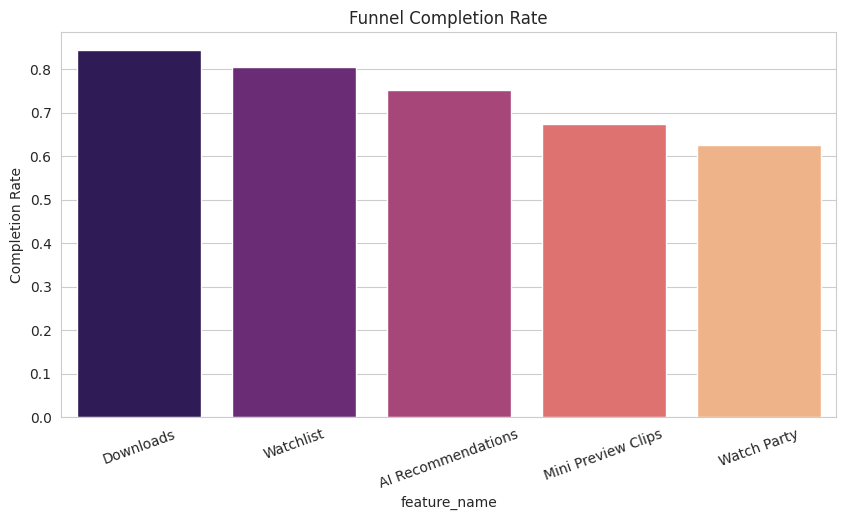

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=completion_analysis.index,
    y=completion_analysis.values,
    palette="magma"
)

plt.title("Funnel Completion Rate")

plt.ylabel("Completion Rate")

plt.xticks(rotation=20)

plt.show()

In [17]:
best_feature = completion_analysis.idxmax()
worst_feature = completion_analysis.idxmin()

print(f"""
INSIGHT:

1. {best_feature} has the strongest
   funnel completion performance.

2. {worst_feature} experiences
   the highest abandonment risk.

3. Low completion indicates
   friction in user experience.
""")


INSIGHT:

1. Downloads has the strongest
   funnel completion performance.

2. Watch Party experiences
   the highest abandonment risk.

3. Low completion indicates
   friction in user experience.



# DROPOFF ANALYSIS

In [18]:
print("=" * 60)
print("DROPOFF ANALYSIS")
print("=" * 60)

dropoff_analysis = (

    df.groupby("feature_name")[
        "dropoff_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(dropoff_analysis)

DROPOFF ANALYSIS
feature_name
Watch Party           0.371107
Mini Preview Clips    0.288170
AI Recommendations    0.183930
Watchlist             0.136630
Downloads             0.116972
Name: dropoff_flag, dtype: float64


/tmp/ipykernel_2409/303863021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


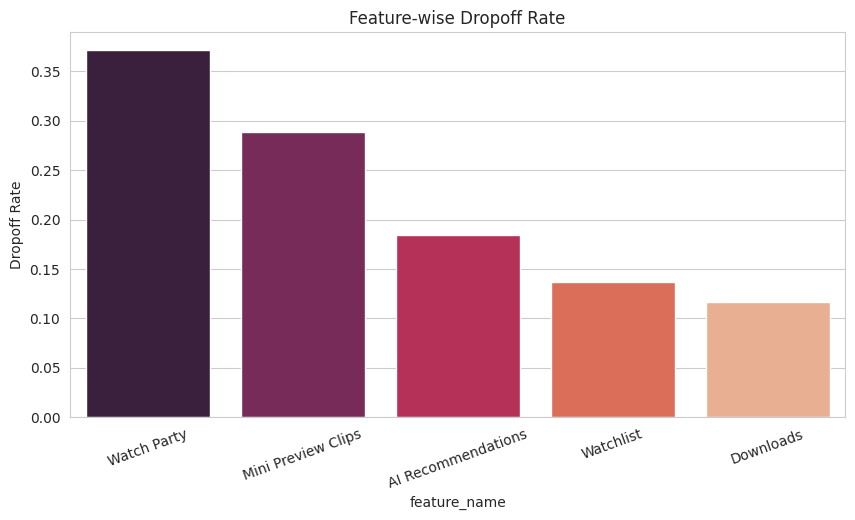

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=dropoff_analysis.index,
    y=dropoff_analysis.values,
    palette="rocket"
)

plt.title("Feature-wise Dropoff Rate")

plt.ylabel("Dropoff Rate")

plt.xticks(rotation=20)

plt.show()

In [20]:
highest_dropoff = dropoff_analysis.idxmax()

print(f"""
INSIGHT:

{highest_dropoff} shows the highest
dropoff rate.

Possible reasons:
- poor UX
- complicated flow
- technical friction
- low feature value
""")


INSIGHT:

Watch Party shows the highest
dropoff rate.

Possible reasons:
- poor UX
- complicated flow
- technical friction
- low feature value



# RAGE CLICK ANALYSIS

In [21]:
print("=" * 60)
print("RAGE CLICK ANALYSIS")
print("=" * 60)

rage_click_analysis = (

    df.groupby("feature_name")[
        "rage_clicks"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(rage_click_analysis)

RAGE CLICK ANALYSIS
feature_name
Watch Party           0.141914
Watchlist             0.116771
Downloads             0.116692
AI Recommendations    0.114537
Mini Preview Clips    0.114011
Name: rage_clicks, dtype: float64


/tmp/ipykernel_2409/2528502748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


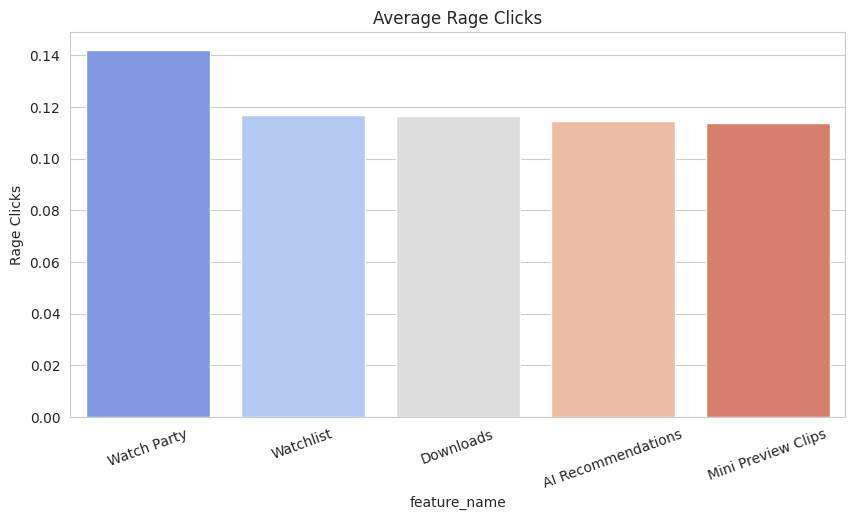

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=rage_click_analysis.index,
    y=rage_click_analysis.values,
    palette="coolwarm"
)

plt.title("Average Rage Clicks")

plt.ylabel("Rage Clicks")

plt.xticks(rotation=20)

plt.show()

In [23]:
highest_rage = rage_click_analysis.idxmax()

print(f"""
INSIGHT:

{highest_rage} generates the highest
rage clicks.

High rage clicks indicate:
- user frustration
- unclear UI
- broken interaction flow
""")


INSIGHT:

Watch Party generates the highest
rage clicks.

High rage clicks indicate:
- user frustration
- unclear UI
- broken interaction flow



# RETRY ANALYSIS

In [24]:
print("=" * 60)
print("RETRY ANALYSIS")
print("=" * 60)

retry_analysis = (

    df.groupby("feature_name")[
        "retries"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(retry_analysis)

RETRY ANALYSIS
feature_name
Watch Party           0.083902
AI Recommendations    0.060846
Mini Preview Clips    0.060706
Downloads             0.059970
Watchlist             0.058083
Name: retries, dtype: float64


/tmp/ipykernel_2409/1487982807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


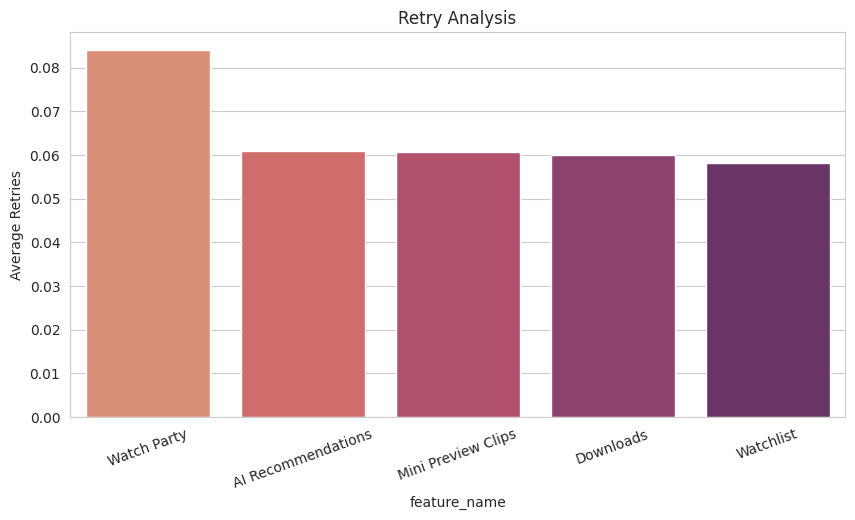

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=retry_analysis.index,
    y=retry_analysis.values,
    palette="flare"
)

plt.title("Retry Analysis")

plt.ylabel("Average Retries")

plt.xticks(rotation=20)

plt.show()

# ERROR ANALYSIS

In [26]:
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

error_analysis = (

    df.groupby("feature_name")[
        "error_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(error_analysis)

ERROR ANALYSIS
feature_name
Watch Party           0.121351
AI Recommendations    0.041096
Downloads             0.039616
Watchlist             0.038547
Mini Preview Clips    0.037558
Name: error_flag, dtype: float64


/tmp/ipykernel_2409/58328251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


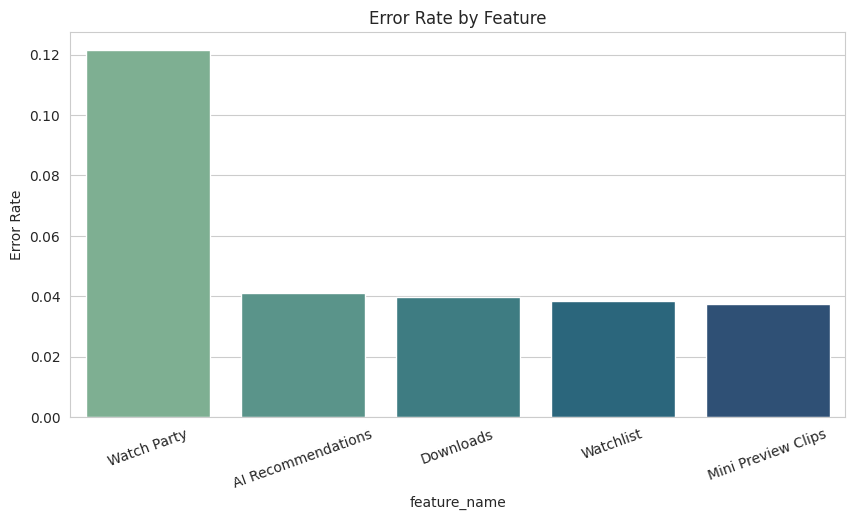

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=error_analysis.index,
    y=error_analysis.values,
    palette="crest"
)

plt.title("Error Rate by Feature")

plt.ylabel("Error Rate")

plt.xticks(rotation=20)

plt.show()

# FRICTION STAGE DETECTION

In [28]:
print("=" * 60)
print("FRICTION STAGE DETECTION")
print("=" * 60)

friction_analysis = (

    df.groupby("funnel_stage")[
        ["rage_clicks", "retries"]
    ]
    .mean()

)

print(friction_analysis)

FRICTION STAGE DETECTION
                        rage_clicks   retries
funnel_stage                                 
Add to Watchlist           0.118000  0.060267
Clicked                    0.142200  0.082400
Content Completed          0.104466  0.071915
Content Opened             0.120241  0.062175
Content Played             0.113265  0.063598
Download Completed         0.123187  0.059727
Download Seen              0.114111  0.060444
Download Started           0.116889  0.060556
Feature Reused             0.106802  0.053505
Friends Invited            0.159302  0.096512
Movie Completed            0.120292  0.062211
Movie Started              0.112721  0.057951
Offline Watch Started      0.120722  0.063902
Preview Seen               0.118000  0.062154
Preview Watched            0.108462  0.056154
Recommendation Clicked     0.114750  0.060875
Recommendation Seen        0.115000  0.061125
Room Created               0.141182  0.085701
Seen                       0.138800  0.081600
Session C

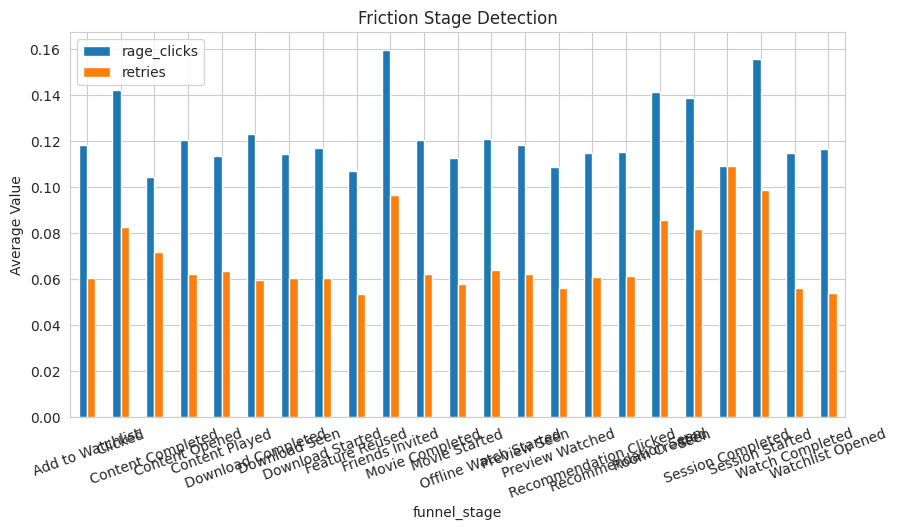

In [29]:
friction_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Friction Stage Detection")

plt.ylabel("Average Value")

plt.xticks(rotation=20)

plt.show()

# DEVICE-WISE DROPOFF ANALYSIS

In [30]:
device_dropoff = (

    df.groupby("device_type")[
        "dropoff_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(device_dropoff)

device_type
smart_tv    0.192032
mobile      0.190840
desktop     0.190778
tablet      0.188164
Name: dropoff_flag, dtype: float64


/tmp/ipykernel_2409/4038147503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


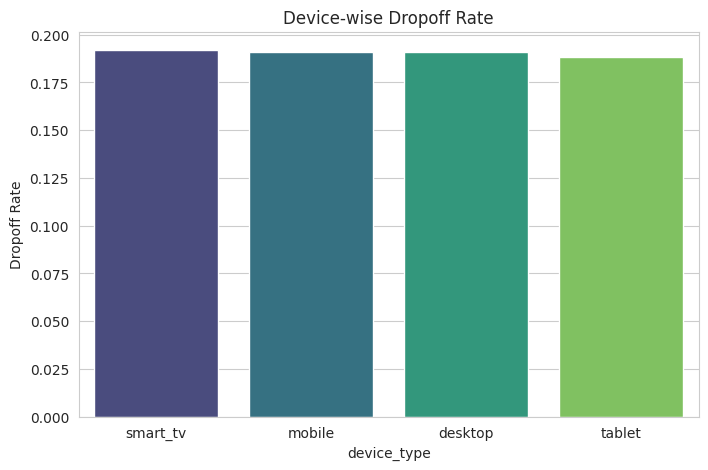

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=device_dropoff.index,
    y=device_dropoff.values,
    palette="viridis"
)

plt.title("Device-wise Dropoff Rate")

plt.ylabel("Dropoff Rate")

plt.show()

# Stage-wise Dropoff Percentage

funnel_stage
Friends Invited           0.775581
Session Started           0.715026
Content Opened            0.638181
Room Created              0.612088
Clicked                   0.556600
Preview Watched           0.438308
Recommendation Clicked    0.380875
Content Played            0.292954
Movie Started             0.272968
Watchlist Opened          0.245333
Download Started          0.226111
Offline Watch Started     0.186984
Download Completed        0.148457
Add to Watchlist          0.000000
Content Completed         0.000000
Download Seen             0.000000
Preview Seen              0.000000
Feature Reused            0.000000
Movie Completed           0.000000
Seen                      0.000000
Recommendation Seen       0.000000
Session Completed         0.000000
Watch Completed           0.000000
Name: dropoff_flag, dtype: float64


/tmp/ipykernel_2409/1670539581.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




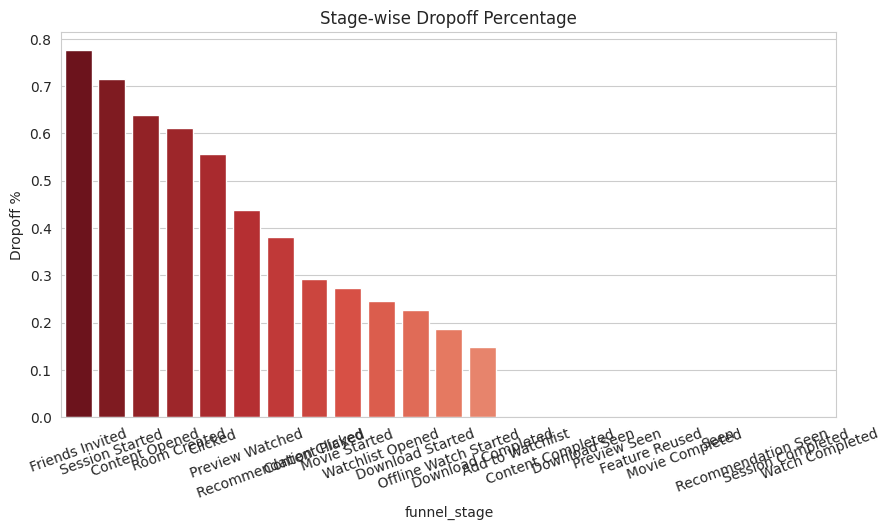

In [43]:
stage_dropoff = (

    df.groupby("funnel_stage")[
        "dropoff_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(stage_dropoff)

plt.figure(figsize=(10,5))

sns.barplot(
    x=stage_dropoff.index,
    y=stage_dropoff.values,
    palette="Reds_r"
)

plt.title(
    "Stage-wise Dropoff Percentage"
)

plt.ylabel("Dropoff %")

plt.xticks(rotation=20)

plt.show()

 # TRAFFIC SOURCE ANALYSIS

In [32]:
traffic_analysis = (

    df.groupby("traffic_source")[
        "stage_completed"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(traffic_analysis)

traffic_source
email       0.768020
ads         0.766949
referral    0.766735
organic     0.761565
Name: stage_completed, dtype: float64


/tmp/ipykernel_2409/1718827200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


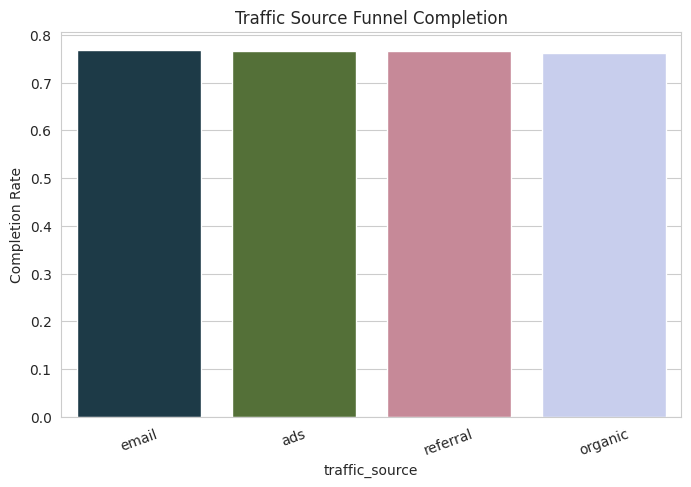

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=traffic_analysis.index,
    y=traffic_analysis.values,
    palette="cubehelix"
)

plt.title("Traffic Source Funnel Completion")

plt.ylabel("Completion Rate")

plt.xticks(rotation=20)

plt.show()

# STAGE-WISE TIME SPENT

In [34]:
time_analysis = (

    df.groupby("funnel_stage")[
        "time_spent_stage_seconds"
    ]
    .mean()

)

print(time_analysis)

funnel_stage
Add to Watchlist           59.151600
Clicked                   121.798600
Content Completed          59.762301
Content Opened             58.057518
Content Played             60.425399
Download Completed        119.645513
Download Seen             118.405111
Download Started          117.701111
Feature Reused            116.656781
Friends Invited           123.640698
Movie Completed            58.500851
Movie Started              60.193110
Offline Watch Started     118.983814
Preview Seen               59.569692
Preview Watched            59.992308
Recommendation Clicked     60.277875
Recommendation Seen        60.003000
Room Created              116.788002
Seen                      121.591200
Session Completed         118.200000
Session Started           131.683938
Watch Completed            60.575385
Watchlist Opened           60.742133
Name: time_spent_stage_seconds, dtype: float64


/tmp/ipykernel_2409/3964336041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


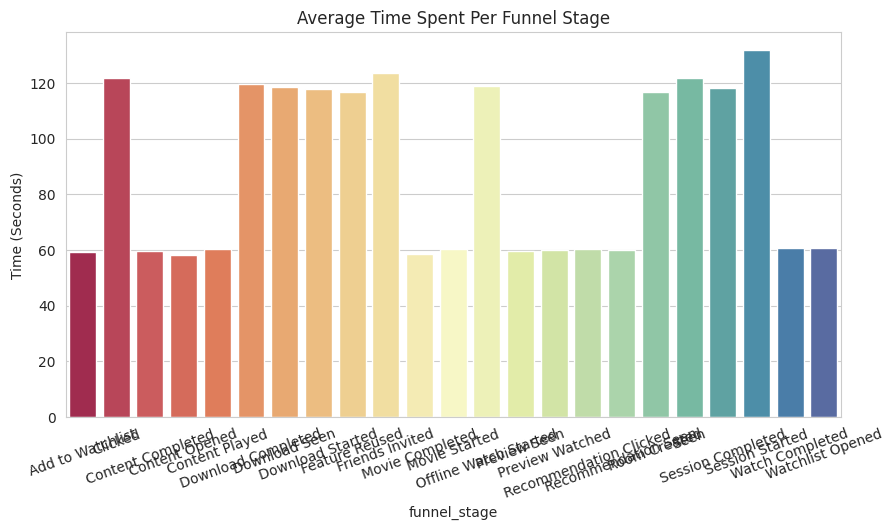

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=time_analysis.index,
    y=time_analysis.values,
    palette="Spectral"
)

plt.title("Average Time Spent Per Funnel Stage")

plt.ylabel("Time (Seconds)")

plt.xticks(rotation=20)

plt.show()

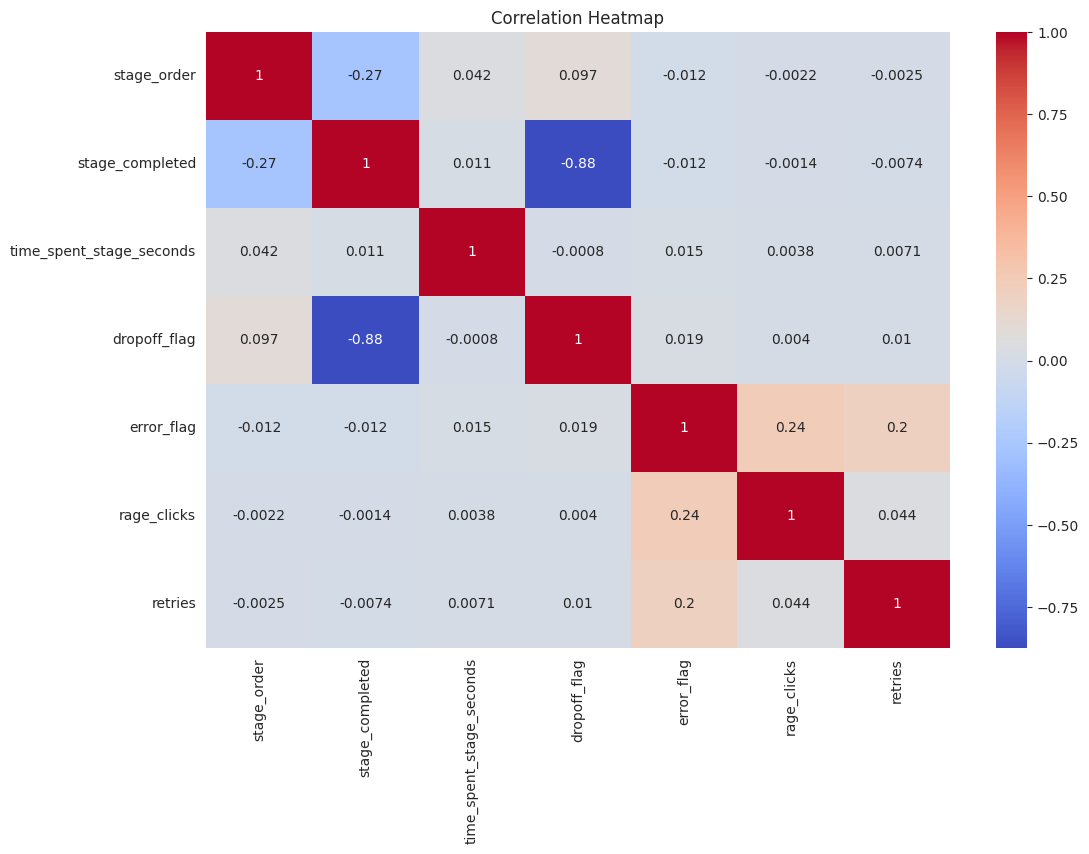

In [36]:
numerical_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

 # MONTHLY DROPOFF TREND

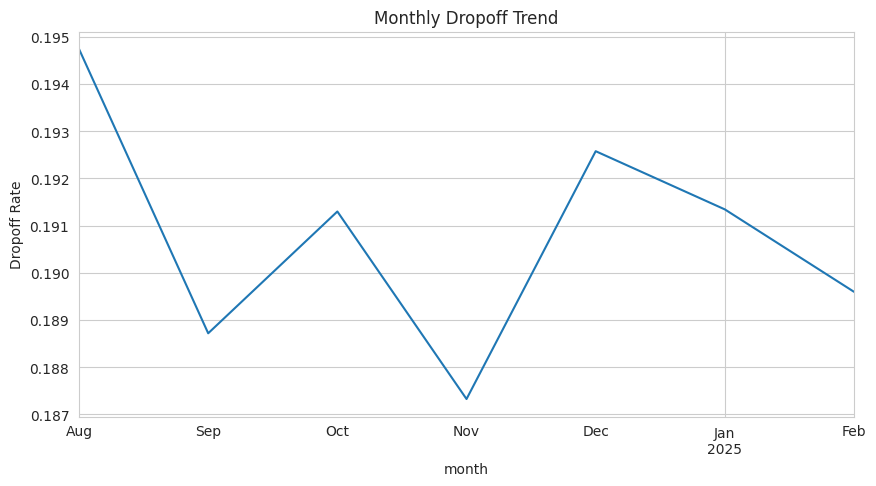

In [37]:
df["month"] = df[
    "timestamp"
].dt.to_period("M")

monthly_dropoff = (

    df.groupby("month")[
        "dropoff_flag"
    ]
    .mean()

)

monthly_dropoff.plot()

plt.title("Monthly Dropoff Trend")

plt.ylabel("Dropoff Rate")

plt.grid(True)

plt.show()

# Rage Click vs Dropoff Scatter Plot

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



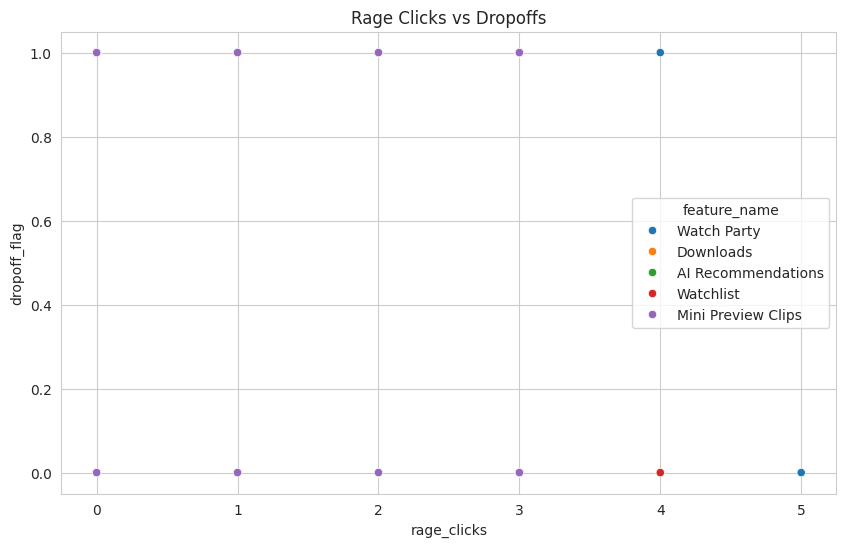

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="rage_clicks",
    y="dropoff_flag",
    hue="feature_name"
)

plt.title(
    "Rage Clicks vs Dropoffs"
)

plt.show()

# Retry vs Error Analysis

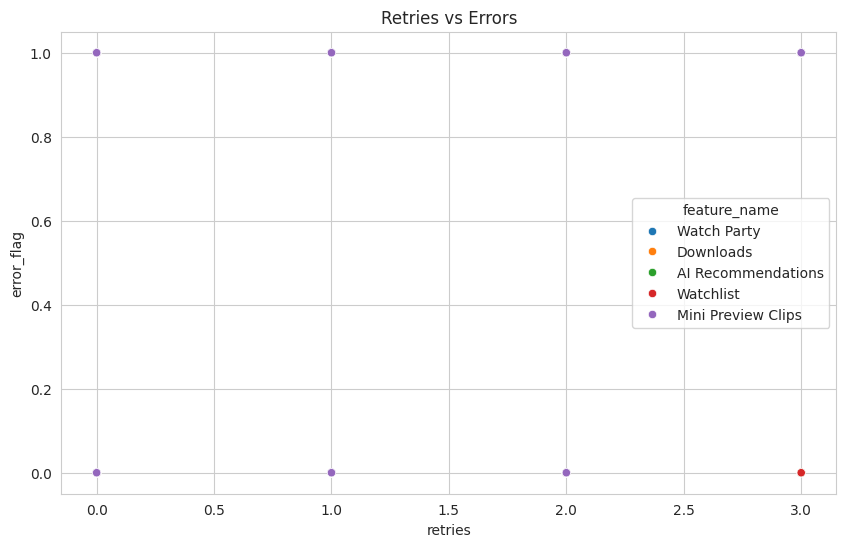

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="retries",
    y="error_flag",
    hue="feature_name"
)

plt.title(
    "Retries vs Errors"
)

plt.show()

# Feature-wise Funnel Heatmap

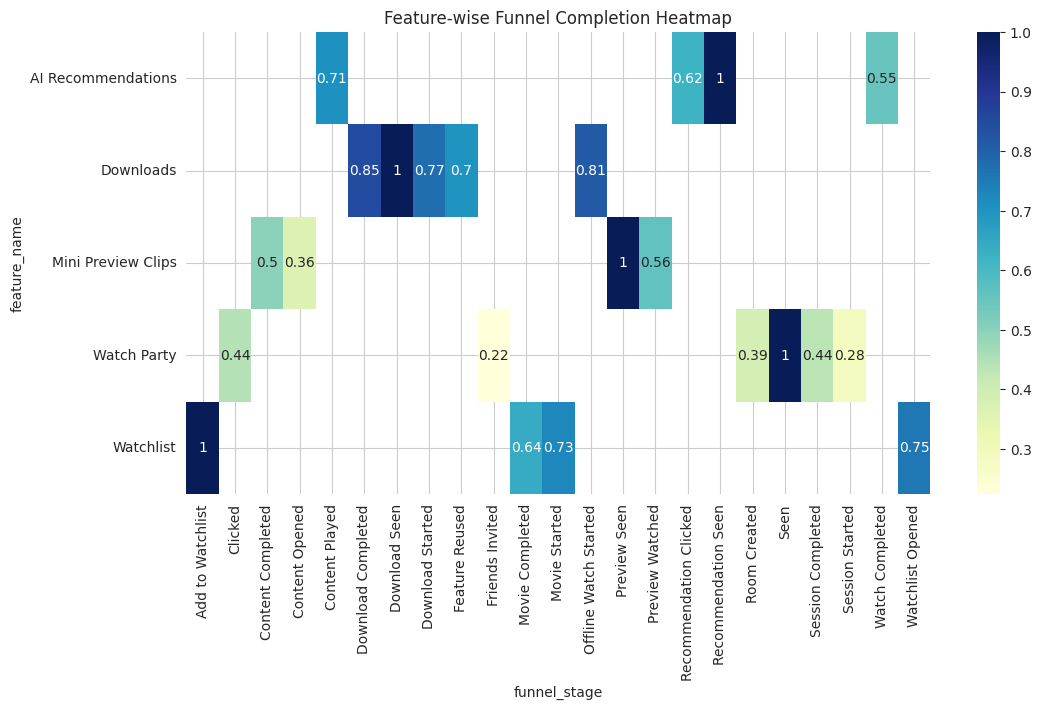

In [46]:
heatmap_data = (

    df.pivot_table(
        values="stage_completed",
        index="feature_name",
        columns="funnel_stage",
        aggfunc="mean"
    )

)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Feature-wise Funnel Completion Heatmap"
)

plt.show()

# High Friction Features Table

In [47]:
friction_table = (

    df.groupby("feature_name")
    .agg({

        "rage_clicks": "mean",

        "retries": "mean",

        "dropoff_flag": "mean",

        "error_flag": "mean"

    })
    .sort_values(
        by="dropoff_flag",
        ascending=False
    )

)

print(friction_table)

                    rage_clicks   retries  dropoff_flag  error_flag
feature_name                                                       
Watch Party            0.141914  0.083902      0.371107    0.121351
Mini Preview Clips     0.114011  0.060706      0.288170    0.037558
AI Recommendations     0.114537  0.060846      0.183930    0.041096
Watchlist              0.116771  0.058083      0.136630    0.038547
Downloads              0.116692  0.059970      0.116972    0.039616


In [38]:
funnel_conversion = (

    df.groupby("funnel_stage")[
        "stage_completed"
    ]
    .sum()

)

print(funnel_conversion)

funnel_stage
Add to Watchlist          7500
Clicked                   2217
Content Completed          657
Content Opened            1321
Content Played            3502
Download Completed        5931
Download Seen             9000
Download Started          6965
Feature Reused            3382
Friends Invited            193
Movie Completed           2642
Movie Started             4115
Offline Watch Started     4822
Preview Seen              6500
Preview Watched           3651
Recommendation Clicked    4953
Recommendation Seen       8000
Room Created               860
Seen                      5000
Session Completed           24
Session Started             55
Watch Completed           1934
Watchlist Opened          5660
Name: stage_completed, dtype: int64


/tmp/ipykernel_2409/518379072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


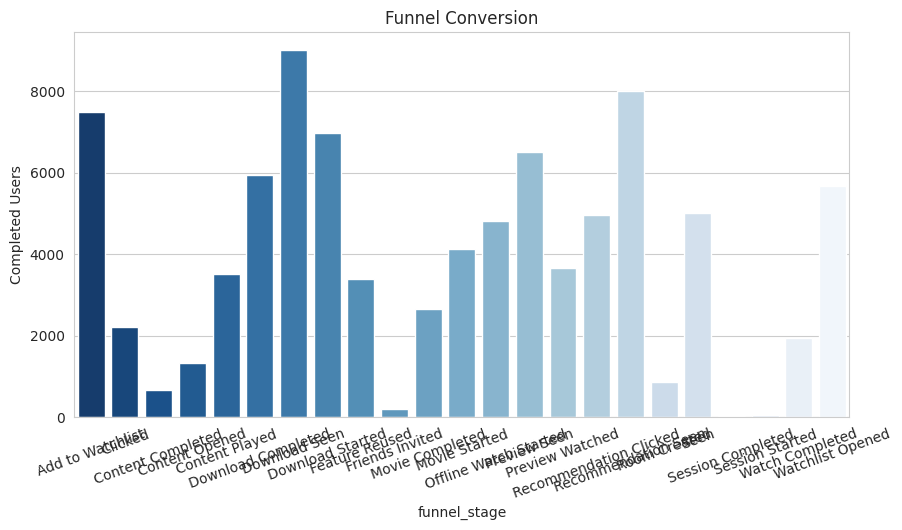

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=funnel_conversion.index,
    y=funnel_conversion.values,
    palette="Blues_r"
)

plt.title("Funnel Conversion")

plt.ylabel("Completed Users")

plt.xticks(rotation=20)

plt.show()

In [40]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

highest_dropoff = dropoff_analysis.idxmax()

highest_rage = rage_click_analysis.idxmax()

best_completion = completion_analysis.idxmax()

print(f"""
1. {best_completion} demonstrates
   the best funnel performance.

2. {highest_dropoff} suffers from
   severe user abandonment.

3. {highest_rage} generates the highest
   frustration signals.

4. Funnel friction is strongly associated
   with retries and rage clicks.

5. Product teams should redesign
   high-friction stages to improve
   retention and conversion.
""")

EXECUTIVE SUMMARY

1. Downloads demonstrates
   the best funnel performance.

2. Watch Party suffers from
   severe user abandonment.

3. Watch Party generates the highest
   frustration signals.

4. Funnel friction is strongly associated
   with retries and rage clicks.

5. Product teams should redesign
   high-friction stages to improve
   retention and conversion.



In [41]:
print("=" * 60)
print("PRODUCT RECOMMENDATIONS")
print("=" * 60)

print("""
1. Reduce funnel complexity
   for high dropoff features.

2. Improve UI responsiveness
   to reduce rage clicks.

3. Optimize onboarding flow
   for weak conversion stages.

4. Reduce retries through
   clearer interaction design.

5. Monitor error-prone stages
   continuously using analytics.
""")

PRODUCT RECOMMENDATIONS

1. Reduce funnel complexity
   for high dropoff features.

2. Improve UI responsiveness
   to reduce rage clicks.

3. Optimize onboarding flow
   for weak conversion stages.

4. Reduce retries through
   clearer interaction design.

5. Monitor error-prone stages
   continuously using analytics.



In [42]:
# =========================================================
# FUNNEL VISUALIZATION
# =========================================================
# PURPOSE:
# Visualize how users move through
# OTT funnel stages.
#
# This shows:
# - stage-wise user completion
# - conversion decline
# - funnel drop-offs
# =========================================================

import plotly.graph_objects as go

# =========================================================
# FUNNEL DATA
# =========================================================

funnel_data = (

    df.groupby("funnel_stage")[
        "stage_completed"
    ]
    .sum()
    .reset_index()

)

print(funnel_data)

# =========================================================
# CREATE FUNNEL CHART
# =========================================================

fig = go.Figure(

    go.Funnel(

        y = funnel_data["funnel_stage"],

        x = funnel_data["stage_completed"],

        textinfo = "value+percent initial"

    )

)

# =========================================================
# LAYOUT
# =========================================================

fig.update_layout(

    title = "OTT Feature Funnel Conversion",

    height = 600,

    width = 900

)

# =========================================================
# SHOW CHART
# =========================================================

fig.show()

              funnel_stage  stage_completed
0         Add to Watchlist             7500
1                  Clicked             2217
2        Content Completed              657
3           Content Opened             1321
4           Content Played             3502
5       Download Completed             5931
6            Download Seen             9000
7         Download Started             6965
8           Feature Reused             3382
9          Friends Invited              193
10         Movie Completed             2642
11           Movie Started             4115
12   Offline Watch Started             4822
13            Preview Seen             6500
14         Preview Watched             3651
15  Recommendation Clicked             4953
16     Recommendation Seen             8000
17            Room Created              860
18                    Seen             5000
19       Session Completed               24
20         Session Started               55
21         Watch Completed      